# 04 -- UpSet vs Venn vs Network: Choosing the Right Visualization

Venn diagrams, UpSet plots, and Network graphs each reveal different facets
of overlapping sets. Picking the wrong one wastes space and confuses readers.
This notebook shows each visualization applied to 3-set, 5-set, and 7-set
data so you can see exactly when each approach shines -- and when it struggles.

**What you will learn:**

- Why Venn diagrams work beautifully for 2-4 sets but deteriorate beyond that
- Why UpSet plots are the recommended alternative for 5+ sets
- When a Network plot adds value regardless of set count


In [1]:
import venn_diagram_lab as vdl

print(f'venn-diagram-lab {vdl.__version__}')

venn-diagram-lab 2.2.3


## Rule-of-thumb: which plot to pick

| Set count | Venn | UpSet | Network | Cluster heatmap |
|-----------|------|-------|---------|-----------------|
| 2-4 sets  | Best -- regions are readable | Works, but overkill | Use for pairwise focus | Useful from N=4 (smaller N has no cluster signal) |
| 5-7 sets  | Gets crowded | **Preferred** -- exact bars, scalable | Useful for clusters and strong edges | **Recommended** -- surfaces catalog groups |
| 8-9 sets  | Avoid -- nearly unreadable | **Recommended** -- threshold filter helps | Helpful with Jaccard/FE edge weights | **Recommended** -- only practical *matrix* view |

A good default rule:

> Use **Venn** for <=4 sets, **UpSet** for >=5 sets, and **Network** whenever
> pairwise overlap strength matters. Add a **Cluster heatmap** whenever the
> audience needs to see *which catalogs group together* (N>=4).


## 3 sets -- Venn is the natural choice

With three sets there are exactly 7 non-empty intersection regions. A Venn diagram
maps them perfectly: each region is visible, labeled, and easy to trace back to
its contributing sets.


In [2]:
# Compact 3-set cancer gene example
ds_3 = vdl.Dataset.from_dict({
    'TP53_Pathway': {'CDKN1A', 'MDM2', 'BAX', 'BBC3', 'PUMA'},
    'Apoptosis':    {'BAX', 'BBC3', 'CASP3', 'CASP9', 'BCL2'},
    'DNA_Repair':   {'CDKN1A', 'BRCA1', 'BRCA2', 'ATM', 'CASP3'},
})
r_3 = vdl.analyze(ds_3, model='auto')
print('Model selected:', r_3.model)
print('Non-empty regions:', len(r_3.regions))

Model selected: venn-3-set
Non-empty regions: 6


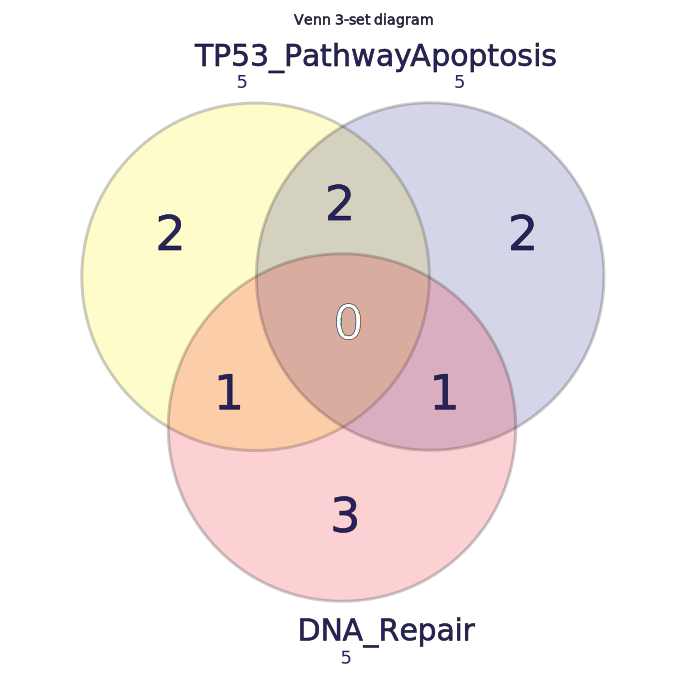

In [3]:
# Venn diagram -- clean and easy to read for 3 sets
r_3.render_venn()

## 5 sets -- Venn becomes crowded

We load a real dataset of MSigDB cancer pathway gene sets (5 sets, all from
Molecular Signatures Database hallmark pathways). The Venn diagram can still
render 31 regions, but many regions overlap visually and the labels compete
for space. Notice how the diagram feels cluttered compared to the 3-set version.


In [4]:
# Real MSigDB cancer pathways dataset (5 sets)
ds_5 = vdl.load_sample('dataset_real_msigdb_cancer_pathways')
r_5 = vdl.analyze(ds_5, model='auto')
print('Set names:', ds_5.set_names)
print('Model selected:', r_5.model)
print('Non-empty regions:', len(r_5.regions))

Set names: ['P53_PATHWAY', 'APOPTOSIS', 'G2M_CHECKPOINT', 'E2F_TARGETS', 'DNA_REPAIR']
Model selected: venn-5-set-grunbaum
Non-empty regions: 19


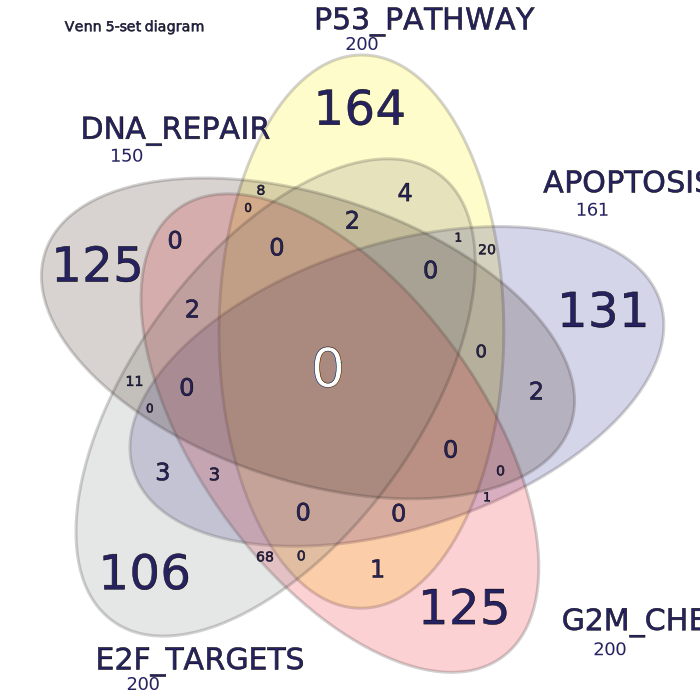

In [5]:
# Venn diagram for 5 sets -- readable but getting busy
r_5.render_venn()

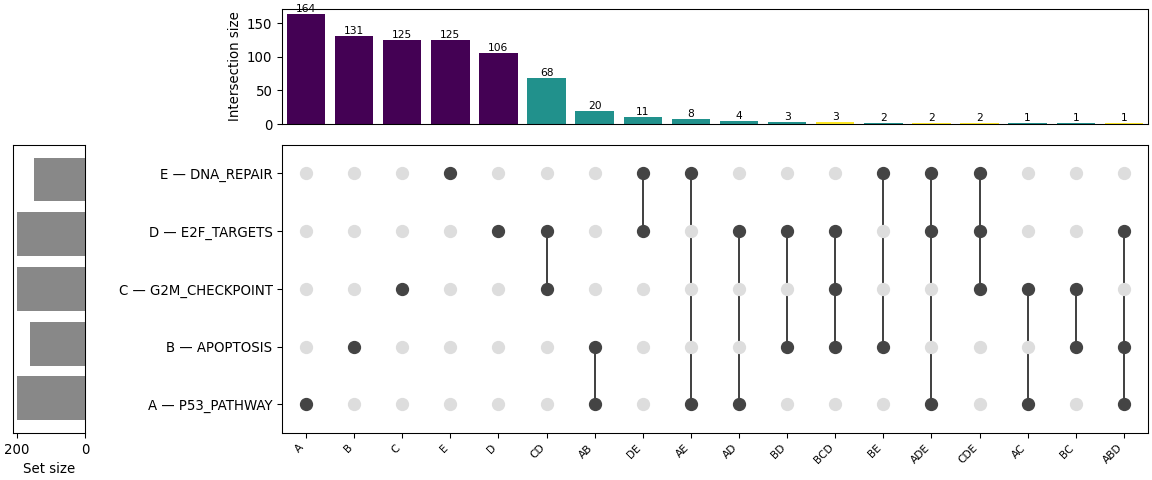

In [6]:
# UpSet plot for 5 sets -- recommended alternative
# Each bar represents one intersection; the dot matrix shows which sets contribute.
r_5.render_upset()

## 7 sets -- UpSet is essential

A 7-set Venn diagram has 127 possible non-empty regions. Even the best template
cannot make that legible. UpSet collapses the visual complexity to a ranked
bar chart: the tallest bars are the biggest intersections, and you can filter
to show only the most populated ones.

We generate a synthetic 7-set dataset where each set has 20 unique items plus
one item (`'shared'`) present in all sets.


In [7]:
# Synthetic 7-set dataset: 20 unique items per set + 1 shared item
ds_7 = vdl.Dataset.from_dict(
    {chr(ord('A') + i): {f'item{j}{i}' for j in range(20)} | {'shared'}
     for i in range(7)}
)
r_7 = vdl.analyze(ds_7, model='auto')
print('Model selected:', r_7.model)
print('Total possible regions:', len(r_7.regions))

Model selected: venn-7-set-grunbaum
Total possible regions: 127


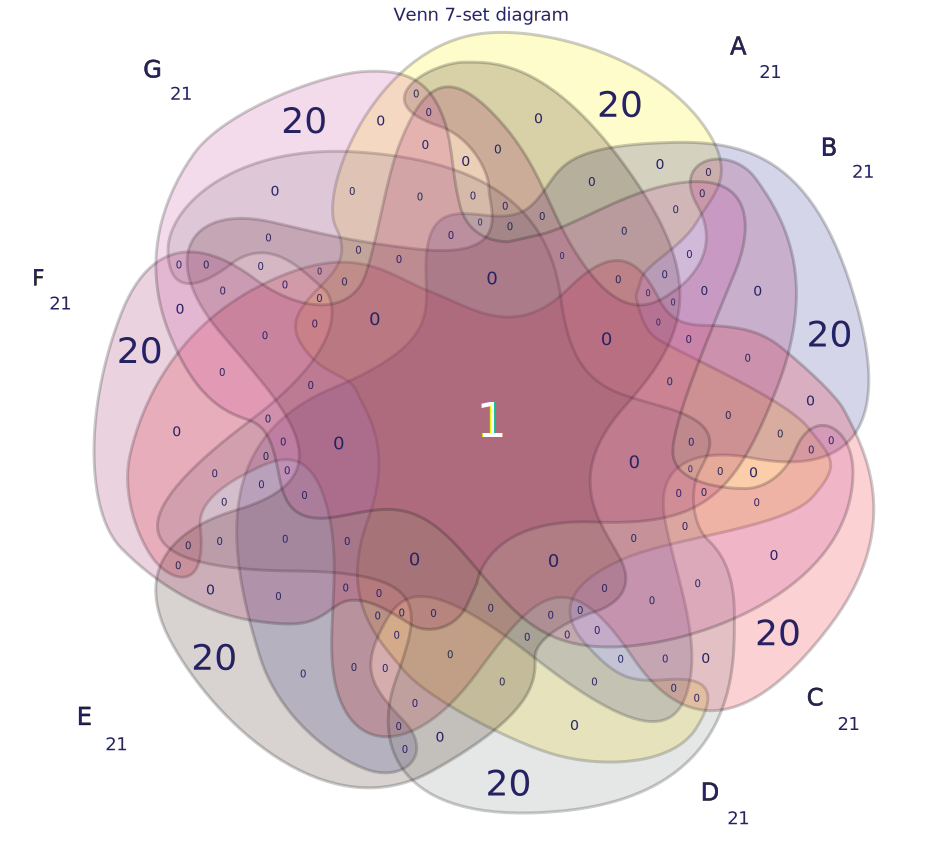

In [8]:
# Venn diagram for 7 sets -- note how overwhelming this becomes
r_7.render_venn()

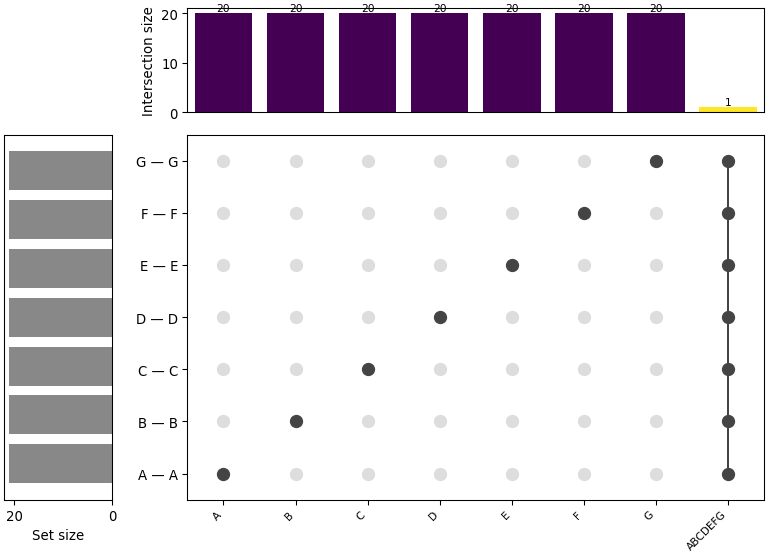

In [9]:
# UpSet plot for 7 sets -- all intersections ranked by size
r_7.render_upset()

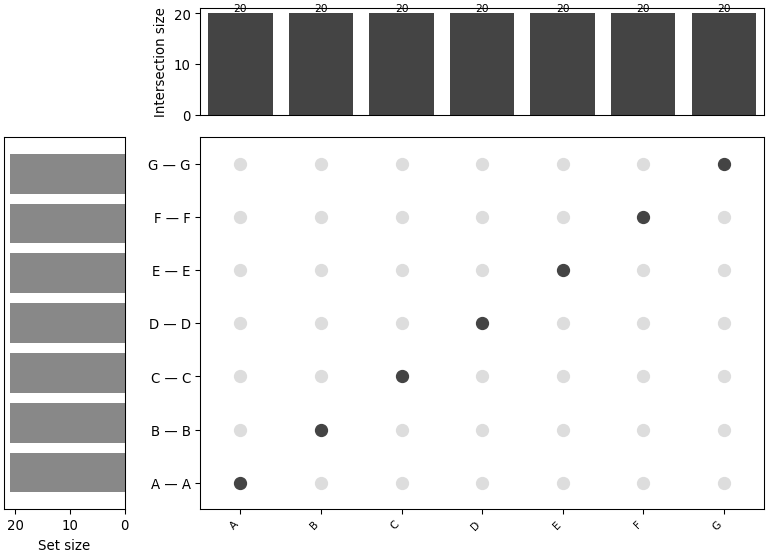

In [10]:
# Threshold filter: show only intersections with >= 2 items
# This removes noise and highlights meaningful overlaps.
r_7.render_upset(threshold=2)

## Network plot -- relationship-focused view

The Network plot represents sets as nodes and pairwise overlaps as edges.
Edge weight and color reflect overlap strength (Jaccard similarity by default).
It answers a different question: *which sets are most similar to each other?*

The 5-set cancer dataset works well here because the pathway groupings
create a meaningful cluster structure.


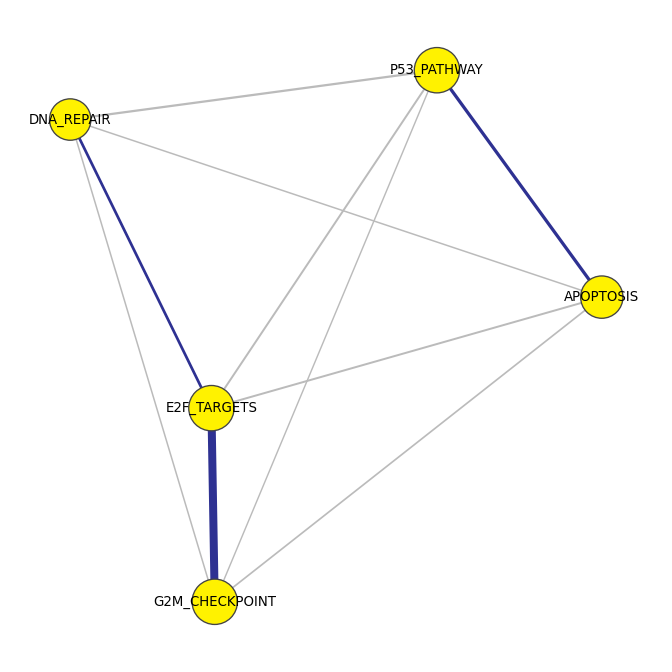

In [11]:
# Network plot for the 5-set cancer dataset
# Node size = set cardinality, edge weight = pairwise Jaccard similarity.
r_5.render_network()

## Option 4: Cluster Heatmap (v2.2.3)

The Cluster Heatmap renders the pairwise Jaccard similarity matrix with
UPGMA-reordered axes and L-shaped dendrograms. Where the Network plot
answers *what are the strongest individual edges?*, the Cluster Heatmap
answers *which sets form natural groups?* -- a useful complement when
the dataset has 4+ sets with non-trivial structure.

Below we render it on the same 5-set MSigDB pathway dataset used in the
UpSet and Network sections, so direct comparison is easy.


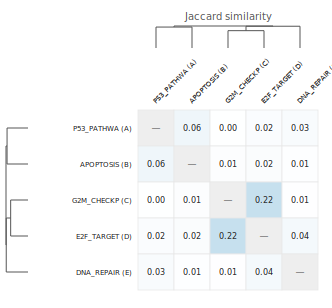

In [12]:
# Cluster heatmap for the 5-set MSigDB pathway dataset.
# linkage='average' is UPGMA; rows + cols share the same leaf order so
# the diagonal stays at 1.0 even after reordering.
from venn_diagram_lab.render.svg import render_cluster_heatmap_svg

render_cluster_heatmap_svg(r_5, linkage='average')

## Matplotlib-native Venn (for paper-figure composition)

When you want a Venn inside your own matplotlib subplot grid (e.g.
the leftmost panel of a 4-panel figure), `render_venn_mpl(result, ax=...)`
draws directly into the provided Axes and returns an `MplImage`.
Supports 2/3/4-set classic Venns and area-proportional 2/3-set
layouts. Higher set counts raise `IncompatibleModelError` -- use
`render_venn_svg` for those.


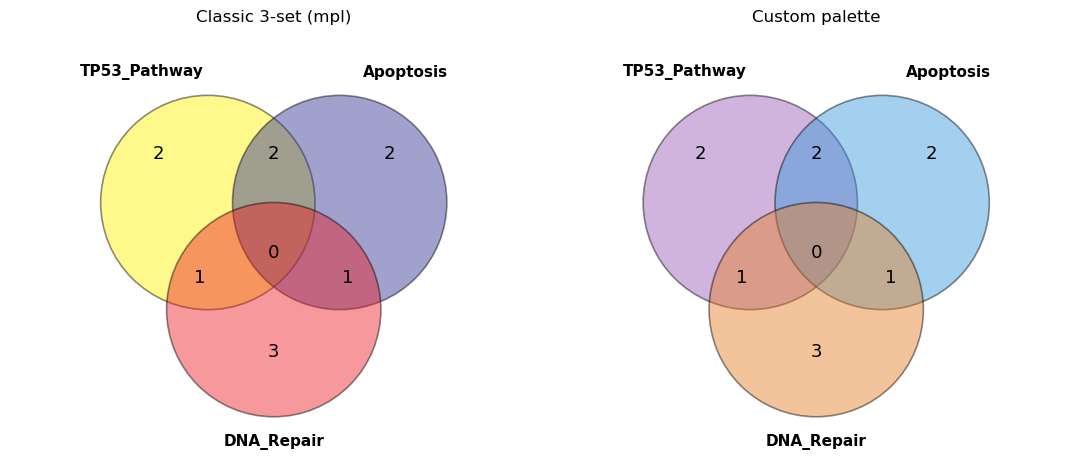

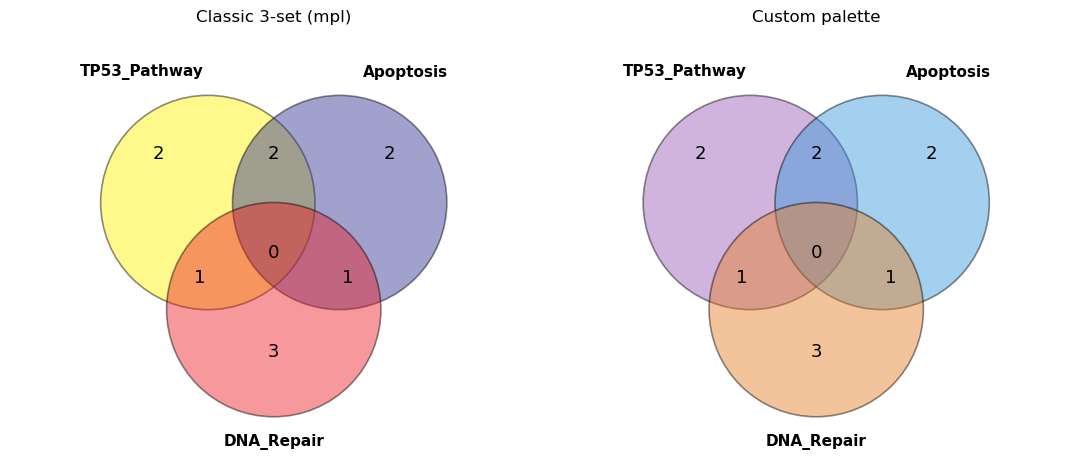

In [13]:
import matplotlib.pyplot as plt
from venn_diagram_lab import render_venn_mpl

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
render_venn_mpl(r_3, ax=ax[0], title='Classic 3-set (mpl)')
render_venn_mpl(r_3, ax=ax[1], colors={'A': '#9b59b6', 'B': '#3498db',
                                       'C': '#e67e22'},
                title='Custom palette')
fig.tight_layout()
fig


## Closing decision: four families, four questions

| Plot | Answers... | Best at | Limits |
|------|-----------|---------|--------|
| Venn | *Which items are in this exact subset?* | 2-4 sets | Crowded at N>=5 |
| UpSet | *Which intersections are largest?* | 5-9 sets | Loses spatial context |
| Network | *Which pairs overlap most?* | Any N | Shows only pairwise edges |
| Cluster heatmap | *Which sets group together?* | N>=4 | Symmetric only |

Real publications often combine two or more: a Venn or UpSet as the
primary figure, plus a Cluster heatmap or Network in the supplement to
support the narrative.


## Next steps

- [`05_statistics_deep_dive.ipynb`](05_statistics_deep_dive.ipynb) -- Jaccard, Dice, and hypergeometric enrichment explained with real data
- [`07_pdf_reports.ipynb`](07_pdf_reports.ipynb) -- generate a publication-ready multi-page PDF report combining Venn, UpSet, Network, and statistics
